CONTROLLED TEST OUTPUT (× FORMAT)

Case 1: Low B / Low D
State: [0.9 0.2 0.  0.3 0.4]
Selected Action: ×2.0

Case 2: Low B / Dense
State: [0.9 0.2 0.  0.6 0.9]
Selected Action: ×3.0

Case 3: Med B / Low D
State: [0.8 1.  0.1 0.3 0.4]
Selected Action: ×1.0

Case 4: Med B / Medium D
State: [0.8 1.  0.2 0.5 0.5]
Selected Action: ×0.5

Case 5: Med B / High D
State: [0.8 1.  0.3 0.9 0.7]
Selected Action: ×0.5

Case 6: Med B / Sparse
State: [0.8 1.  0.1 0.4 0.2]
Selected Action: ×1.0

Case 7: Med B / Stable
State: [0.8 1.  0.  0.5 0.5]
Selected Action: ×1.0

Case 8: High B / Falling
State: [ 0.5  2.  -0.4  0.6  0.6]
Selected Action: ×0.5

Case 9: Low Inv / Critical
State: [0.2 2.5 0.5 0.9 0.9]
Selected Action: ×0.0

Case 10: Very Low Inv
State: [0.1 1.5 0.4 0.8 0.9]
Selected Action: ×0.0

Case 11: High Inv / Low B
State: [1.  0.2 0.  0.4 0.3]
Selected Action: ×2.0

Case 12: High Inv / High B
State: [1.  2.  0.4 0.7 0.7]
Selected Action: ×3.0

Case 13: Very High Inv
State: [1.  0.1 0.  0.5 0.

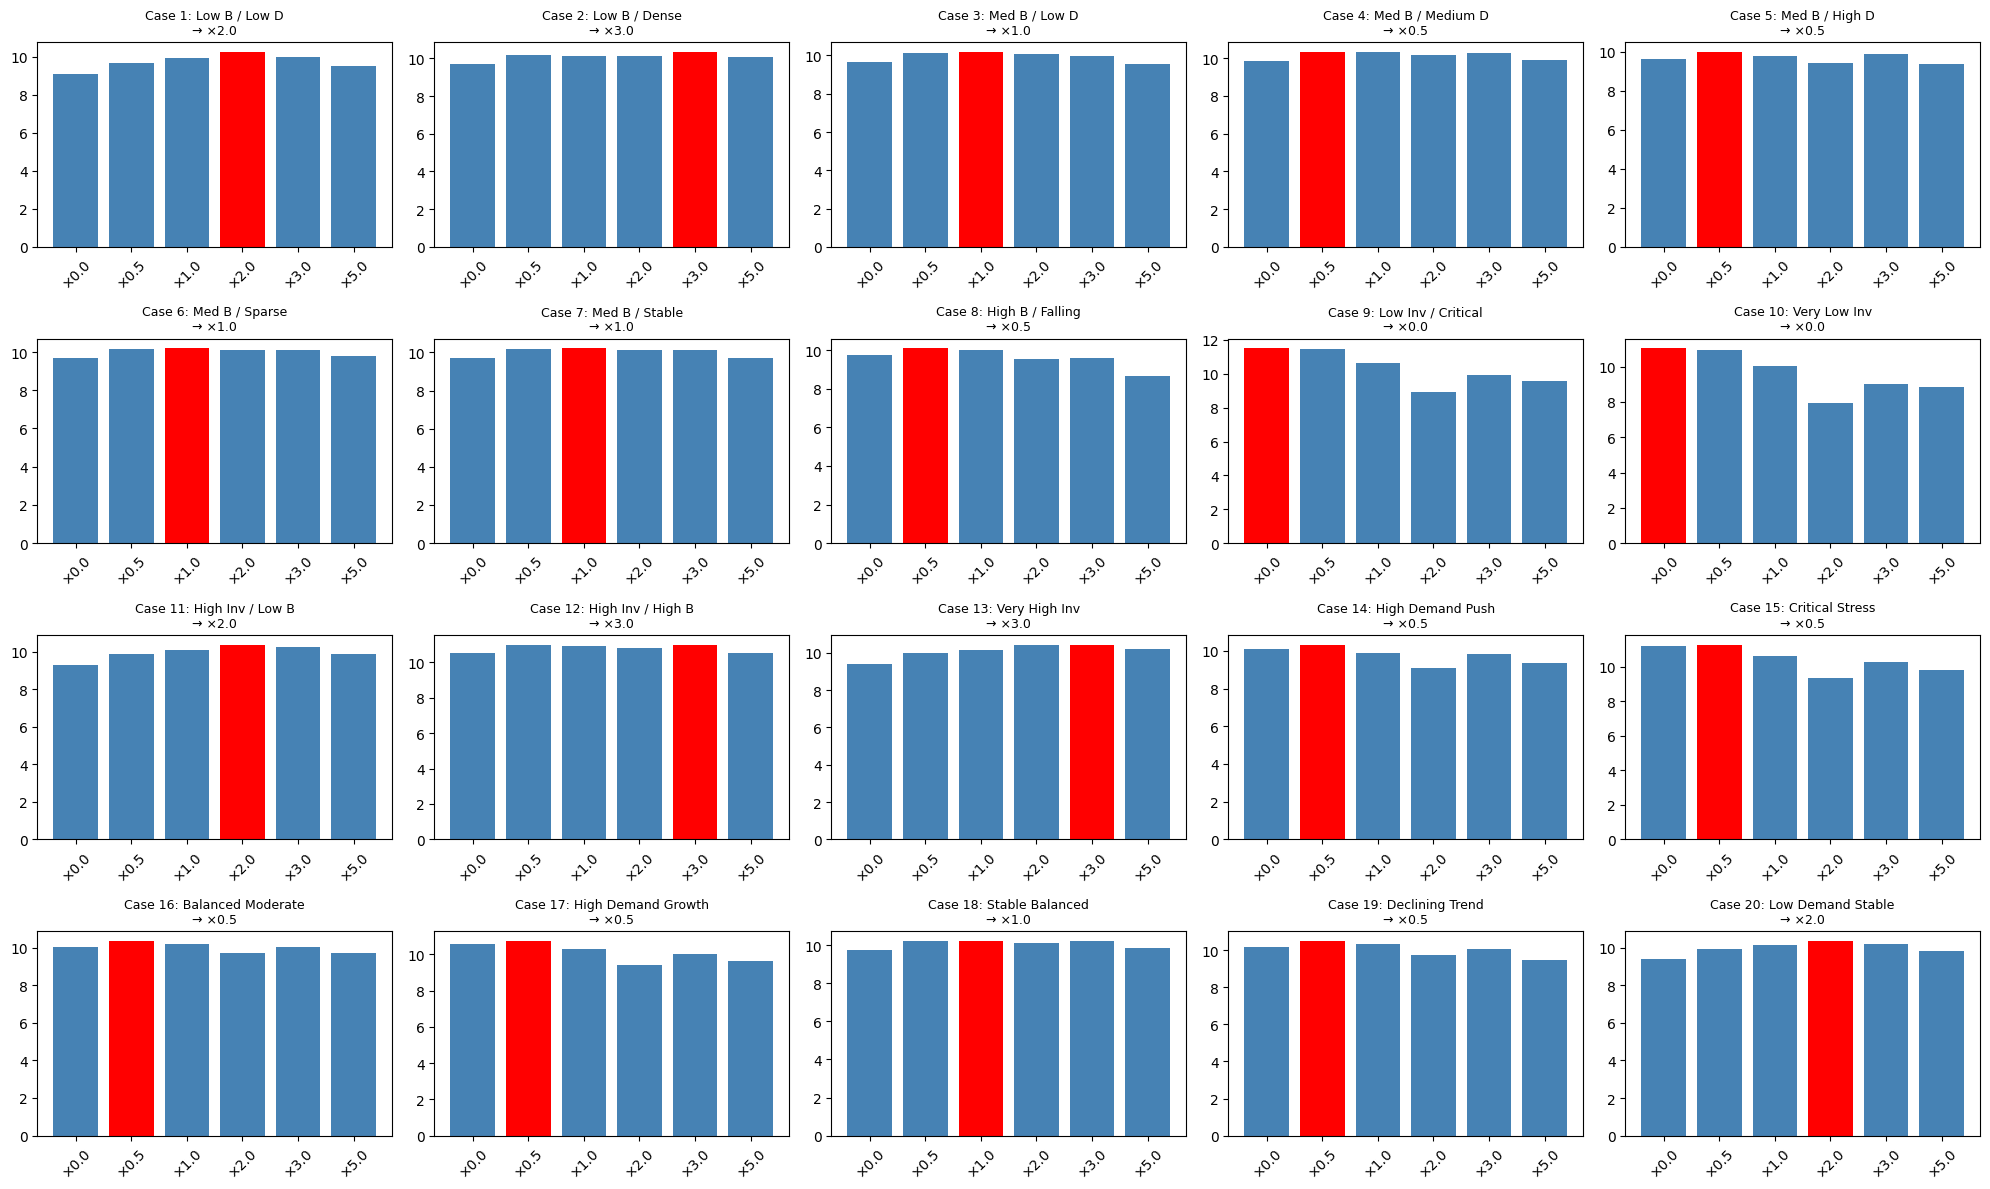

In [ ]:
# ==============================
# DQN DEMO: CONTROLLED 20 CASE TEST (GRID VIEW)
# ==============================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# ------------------------------
# PATHS
# ------------------------------
BASE_PATH = "/content"

MODEL_PATH = os.path.join(BASE_PATH, "trained_model.pth")
CONFIG_PATH = os.path.join(BASE_PATH, "config.pkl")

# ------------------------------
# LOAD CONFIG
# ------------------------------
if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH, "rb") as f:
        config = pickle.load(f)
    action_multipliers = config.get("action_multipliers", [0,1,2,3,4,5])
else:
    action_multipliers = [0, 0.5, 1, 2, 3, 5]

# ------------------------------
# MODEL
# ------------------------------
class DQN(nn.Module):
    def __init__(self, state_dim=5, n_actions=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, x):
        return self.net(x)

model = DQN(5, len(action_multipliers))

state_dict = torch.load(MODEL_PATH, map_location="cpu")
if "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]

fixed = {k.replace("network", "net"): v for k, v in state_dict.items()}
model.load_state_dict(fixed, strict=False)
model.eval()

# ------------------------------
# 20 CONTROLLED CASES (CLEAN NAMES)
# ------------------------------
test_cases = [
    ("Case 1: Low B / Low D",        [0.9, 0.2, 0.0, 0.3, 0.4]),
    ("Case 2: Low B / Dense",        [0.9, 0.2, 0.0, 0.6, 0.9]),

    ("Case 3: Med B / Low D",        [0.8, 1.0, 0.1, 0.3, 0.4]),
    ("Case 4: Med B / Medium D",     [0.8, 1.0, 0.2, 0.5, 0.5]),
    ("Case 5: Med B / High D",       [0.8, 1.0, 0.3, 0.9, 0.7]),
    ("Case 6: Med B / Sparse",       [0.8, 1.0, 0.1, 0.4, 0.2]),
    ("Case 7: Med B / Stable",       [0.8, 1.0, 0.0, 0.5, 0.5]),

    ("Case 8: High B / Falling",     [0.5, 2.0, -0.4, 0.6, 0.6]),

    ("Case 9: Low Inv / Critical",   [0.2, 2.5, 0.5, 0.9, 0.9]),
    ("Case 10: Very Low Inv",        [0.1, 1.5, 0.4, 0.8, 0.9]),

    ("Case 11: High Inv / Low B",    [1.0, 0.2, 0.0, 0.4, 0.3]),
    ("Case 12: High Inv / High B",   [1.0, 2.0, 0.4, 0.7, 0.7]),
    ("Case 13: Very High Inv",       [1.0, 0.1, 0.0, 0.5, 0.4]),

    ("Case 14: High Demand Push",    [0.7, 1.5, 0.5, 1.0, 0.9]),
    ("Case 15: Critical Stress",     [0.5, 2.5, 0.6, 1.0, 1.0]),

    ("Case 16: Balanced Moderate",   [0.7, 1.2, 0.3, 0.6, 0.6]),
    ("Case 17: High Demand Growth",  [0.6, 1.8, 0.4, 0.8, 0.8]),
    ("Case 18: Stable Balanced",     [0.8, 0.9, 0.2, 0.5, 0.5]),
    ("Case 19: Declining Trend",     [0.6, 1.3, -0.2, 0.7, 0.7]),
    ("Case 20: Low Demand Stable",   [0.9, 0.5, 0.1, 0.4, 0.4]),
]

# ------------------------------
# RUN TESTS (GRID)
# ------------------------------
print("=" * 50)
print("CONTROLLED TEST OUTPUT (× FORMAT)")
print("=" * 50)

rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes = axes.flatten()

for idx, (name, state) in enumerate(test_cases):
    state_np = np.array(state, dtype=np.float32)
    state_tensor = torch.FloatTensor(state_np).unsqueeze(0)

    with torch.no_grad():
        q_values = model(state_tensor).numpy().flatten()

    action_idx = int(np.argmax(q_values))
    multiplier = action_multipliers[action_idx]

    # Console output
    print(f"\n{name}")
    print(f"State: {state_np}")
    print(f"Selected Action: ×{multiplier}")

    # ------------------------------
    # SUBPLOT
    # ------------------------------
    ax = axes[idx]

    x_labels = [f"×{m}" for m in action_multipliers]

    # Highlight best action
    colors = ["red" if i == action_idx else "steelblue"
              for i in range(len(action_multipliers))]

    ax.bar(x_labels, q_values, color=colors)

    ax.set_title(f"{name}\n→ ×{multiplier}", fontsize=9)
    ax.tick_params(axis='x', rotation=45)

# Remove unused axes (safety)
for i in range(len(test_cases), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()